In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from itertools import combinations

In [2]:
all_pairs_table = pd.read_table('../POST-PROCESS-ALL-PAIRS-2023-07-20/post-processing_all_bins.tsv')
feasible_mask = all_pairs_table['MILP_INFEASIBLE'] == 0
overlap_mask = all_pairs_table['BINS_OVERLAP'] == 1
print(sum(all_pairs_table[~feasible_mask]['MILP_INFEASIBLE']))
print(sum(all_pairs_table[overlap_mask]['BINS_OVERLAP']))

282
390


In [3]:
for col in all_pairs_table.columns:
    print(col, all_pairs_table[col].dtype)

SAMPLE object
BIN1 object
BIN1_GC_BIN int64
BIN1_GC float64
BIN1_GD float64
BIN1_RD float64
BIN2 object
BIN2_GC_BIN int64
BIN2_GC float64
BIN2_GD float64
BIN2_RD float64
MERGE_GC_BIN int64
MERGE_GC float64
MERGE_GD float64
MERGE_RD float64
MERGE_PATH object
MILP_INFEASIBLE int64
BINS_OVERLAP int64


In [4]:
# checks if S is contained in any set in list of sets
def set_in_sets(S, sets):
    for T in sets:
        if S & T == S:
            return True
    return False

pd.set_option('display.max_colwidth', None)
disjoint_pairs_table = pd.read_table('../../test/split_bins.tsv')

non_empty_mask = disjoint_pairs_table['PRED_IDS'].notna()
disjoint_pairs_table = disjoint_pairs_table[non_empty_mask].reset_index(drop=True)
pred_ids_per_gt_plasmid = disjoint_pairs_table[['SAMPLE', 'PRED_IDS']].groupby('SAMPLE').agg(list)
pred_ids_per_gt_plasmid['PRED_IDS'] = pred_ids_per_gt_plasmid['PRED_IDS'].apply(lambda x: [set(y[1:-1].split(sep=',')) for y in x])

all_pairs_table = all_pairs_table.join(pred_ids_per_gt_plasmid, on='SAMPLE', how='left')
all_pairs_table.rename({'PRED_IDS':'GT_SPLITS'}, axis='columns', inplace=True)
all_pairs_table['GOOD_MERGE_CANDIDATES'] = all_pairs_table.apply(lambda row: set_in_sets(set([row['BIN1'], row['BIN2']]), row['GT_SPLITS']) if type(row['GT_SPLITS']) != float else False, axis=1)
good_candidates_mask = all_pairs_table['GOOD_MERGE_CANDIDATES'] == True
print(all_pairs_table[good_candidates_mask][['SAMPLE', 'BIN1', 'BIN2', 'GT_SPLITS']])

          SAMPLE    BIN1     BIN2  \
2     sample_102  pbf_P1   pbf_P2   
10    sample_108  pbf_P0   pbf_P2   
17    sample_109  pbf_P1   pbf_P2   
30    sample_112  pbf_P1   pbf_P2   
31    sample_112  pbf_P1   pbf_P3   
...          ...     ...      ...   
1327   sample_85  pbf_P0   pbf_P2   
1332   sample_86  pbf_P0   pbf_P1   
1373   sample_87  pbf_P4   pbf_P5   
1376   sample_87  pbf_P4  pbf_P10   
1379   sample_87  pbf_P5  pbf_P10   

                                            GT_SPLITS  
2                        [{pbf_P0}, {pbf_P1, pbf_P2}]  
10                       [{pbf_P1}, {pbf_P0, pbf_P2}]  
17             [{pbf_P0}, {pbf_P1, pbf_P2}, {pbf_P4}]  
30               [{pbf_P0}, {pbf_P1, pbf_P3, pbf_P2}]  
31               [{pbf_P0}, {pbf_P1, pbf_P3, pbf_P2}]  
...                                               ...  
1327                               [{pbf_P0, pbf_P2}]  
1332           [{pbf_P1, pbf_P0}, {pbf_P2}, {pbf_P8}]  
1373  [{pbf_P4, pbf_P10, pbf_P5}, {pbf_P3}, {pbf_P9

<Axes: xlabel='POST_OBJ', ylabel='COMBINED_OBJ'>

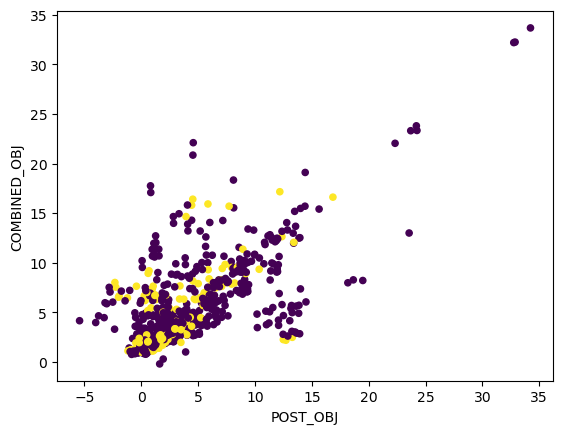

In [5]:
colour_mask = all_pairs_table[feasible_mask & ~overlap_mask]['GOOD_MERGE_CANDIDATES']
all_pairs_table['POST_OBJ'] = all_pairs_table[['MERGE_GC', 'MERGE_GD', 'MERGE_RD']].sum(axis=1)
all_pairs_table['COMBINED_OBJ'] = all_pairs_table[['BIN1_GC', 'BIN1_GD', 'BIN2_GC', 'BIN2_GD']].sum(axis=1) + \
                                  (all_pairs_table[['BIN1_RD', 'BIN2_RD']].sum(axis=1) / 2)
all_pairs_table[feasible_mask & ~overlap_mask].plot.scatter(x='POST_OBJ', y='COMBINED_OBJ', c=colour_mask)
#feasible_disjoint = all_pairs_table[feasible_mask & ~overlap_mask]
#plot_range = math.ceil(max(feasible_disjoint['POST_OBJ'].max(), feasible_disjoint['COMBINED_OBJ'].max()))
#plt.plot(range(plot_range), c='red')
#plt.scatter(x=feasible_disjoint['POST_OBJ'], \
#            y=feasible_disjoint['COMBINED_OBJ'], c=colour_mask, s=20)

<Axes: xlabel='POST_OBJ', ylabel='COMBINED_OBJ'>

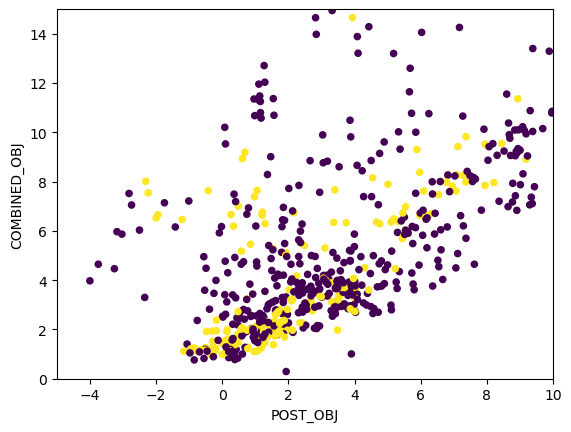

In [6]:
all_pairs_table[feasible_mask & ~overlap_mask].plot.scatter(x='POST_OBJ', y='COMBINED_OBJ', c=colour_mask, \
                                                            xlim=[-5, 10], ylim=[0, 15])

<Axes: xlabel='POST_RD', ylabel='COMBINED_RD'>

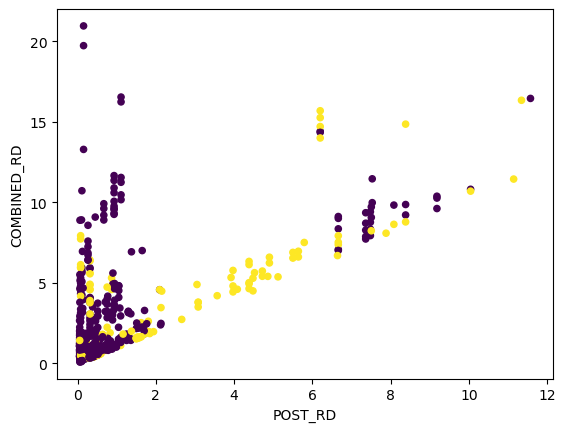

In [7]:
all_pairs_table['POST_RD'] = all_pairs_table['MERGE_RD']
all_pairs_table['COMBINED_RD'] = all_pairs_table[['BIN1_RD', 'BIN2_RD']].sum(axis=1) / 2
all_pairs_table[feasible_mask & ~overlap_mask].plot.scatter(x='POST_RD', y='COMBINED_RD', c=colour_mask)

<Axes: xlabel='POST_RD', ylabel='COMBINED_RD'>

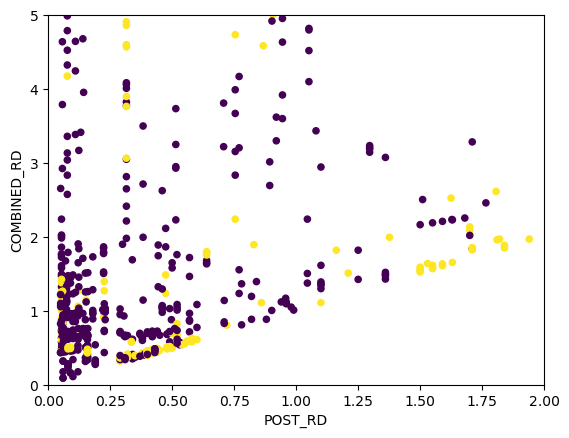

In [8]:
all_pairs_table[feasible_mask & ~overlap_mask].plot.scatter(x='POST_RD', y='COMBINED_RD', c=colour_mask, \
                                                            xlim=[0, 2], ylim=[0, 5])

<Axes: xlabel='POST_GD', ylabel='COMBINED_GD'>

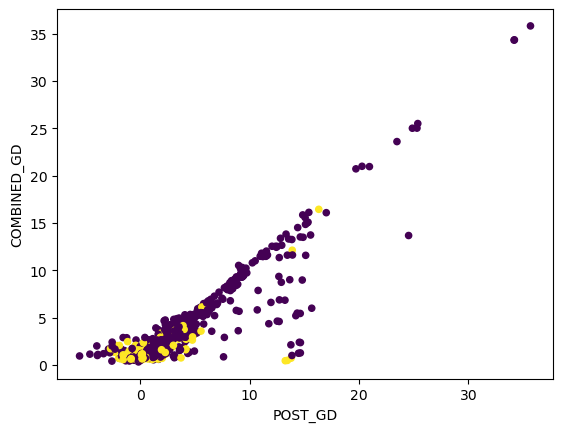

In [9]:
all_pairs_table['POST_GD'] = all_pairs_table['MERGE_GD']
all_pairs_table['COMBINED_GD'] = all_pairs_table[['BIN1_GD', 'BIN2_GD']].sum(axis=1)
all_pairs_table[feasible_mask & ~overlap_mask].plot.scatter(x='POST_GD', y='COMBINED_GD', c=colour_mask)

<Axes: xlabel='POST_GD', ylabel='COMBINED_GD'>

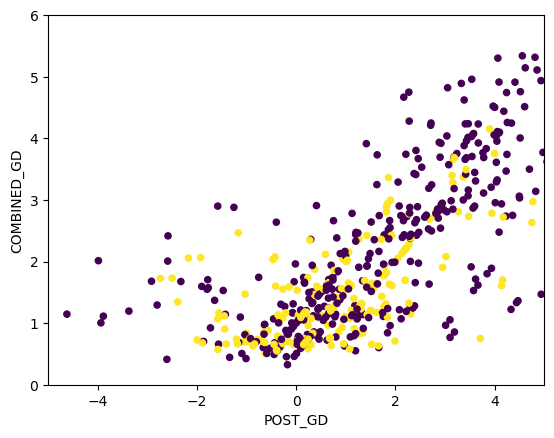

In [10]:
all_pairs_table[feasible_mask & ~overlap_mask].plot.scatter(x='POST_GD', y='COMBINED_GD', c=colour_mask, \
                                                            xlim=[-5, 5], ylim=[0, 6])

<Axes: xlabel='POST_GC', ylabel='COMBINED_GC'>

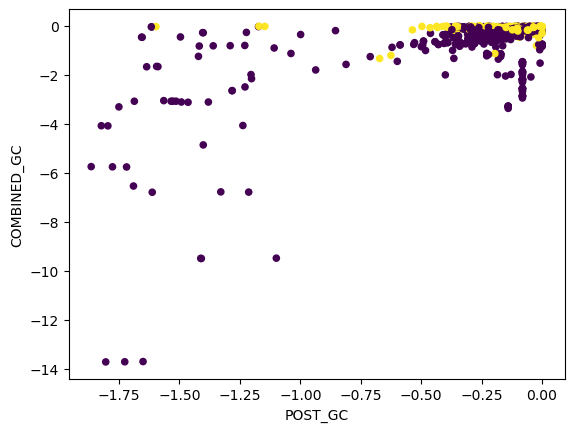

In [11]:
all_pairs_table['POST_GC'] = all_pairs_table['MERGE_GC']
all_pairs_table['COMBINED_GC'] = all_pairs_table[['BIN1_GC', 'BIN2_GC']].sum(axis=1)
all_pairs_table[feasible_mask & ~overlap_mask].plot.scatter(x='POST_GC', y='COMBINED_GC', c=colour_mask)

<Axes: xlabel='POST_GC', ylabel='COMBINED_GC'>

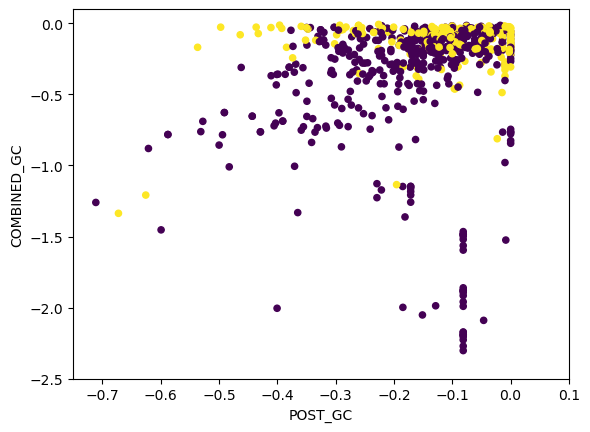

In [12]:
all_pairs_table[feasible_mask & ~overlap_mask].plot.scatter(x='POST_GC', y='COMBINED_GC', c=colour_mask, \
                                                            xlim=[-0.75, 0.1], ylim=[-2.5, 0.1])

<Axes: xlabel='POST_OBJ', ylabel='COMBINED_OBJ'>

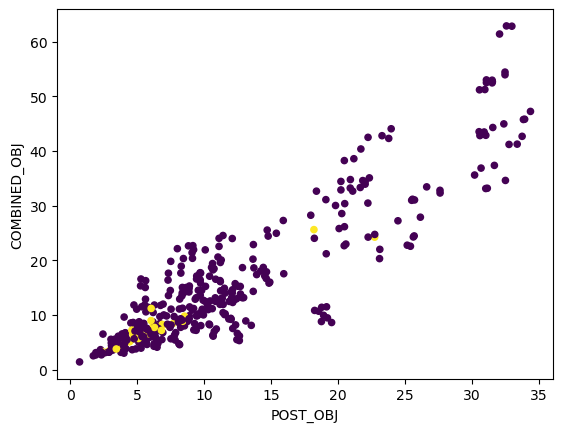

In [13]:
colour_mask = all_pairs_table[overlap_mask]['GOOD_MERGE_CANDIDATES']
all_pairs_table[overlap_mask].plot.scatter(x='POST_OBJ', y='COMBINED_OBJ', c=colour_mask)

<Axes: xlabel='POST_RD', ylabel='COMBINED_RD'>

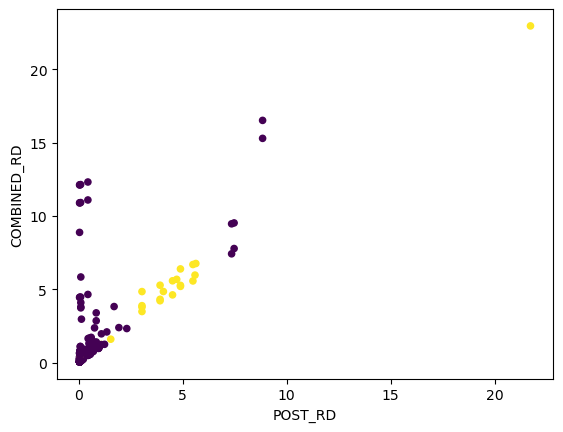

In [14]:
all_pairs_table[overlap_mask].plot.scatter(x='POST_RD', y='COMBINED_RD', c=colour_mask)

In [31]:
import networkx as nx
import os
import sys  
sys.path.insert(0, '../../scripts')
import io_utils as io

for sample in all_pairs_table['SAMPLE'].unique():
    
    G = nx.Graph()
    gt_file = os.path.join('../../../organized_data/ground_truth', sample, 'ctg_pls.tsv')
    pred_file = os.path.join('../../../organized_data/output', sample, 'plasbin_flow_bins.out')
    gc_ints = '../../../organized_data/gc_intervals.txt'
    gt_pls = io.Plasmids('ground_truth', gt_file)
    pred_plasmids = io.PBF_output('plasbin_flow', pred_file, gc_ints)
    sample_table = all_pairs_table[all_pairs_table['SAMPLE'] == sample]
    bins_list = pd.concat([sample_table['BIN1'], sample_table['BIN2']], axis=0).unique()
    gt_ids = pred_plasmids.get_pls_ids()
    gt_ctgs = {gt_id: [ctg[0] for ctg in gt_pls.get_pls(gt_id)]}
    G.add_nodes_from(bins_list)
    edge_list = []
    edge_scores = []
    for index, row in sample_table.iterrows():
        if row['MILP_INFEASIBLE'] == 0:
            edge_list.append((row['BIN1'], row['BIN2']))
            edge_scores.append(row['POST_OBJ'] - row['COMBINED_OBJ'])
    
    pred_ctgs = {bin_id: pred_plasmids.get_pls_ctgs(bin_id, False) for bin_id in bins_list}
    pred_gt_intersection = [bin_id: max()]
    
    pred_closest_to_gt = {bin_id: max([len(set(pred_ctgs[bin_id]) & )]) for bin_id in bins_list} 
    G.add_edges_from(edge_list)
    

dict_keys(['CP011290.1', 'CP011291.1'])
dict_keys(['CP016526.1', 'CP016527.1', 'CP016528.1', 'CP016529.1'])
dict_keys(['CP016515.1', 'CP016516.1'])
dict_keys(['CP012925.1', 'CP012926.1', 'CP012927.1', 'CP012928.1', 'CP012929.1'])
dict_keys(['CP016566.1', 'CP016567.1', 'CP016568.1'])
dict_keys(['CP016570.1', 'CP016571.1', 'CP016572.1'])
dict_keys(['CP016518.1', 'CP016519.1'])
dict_keys(['CP012931.1', 'CP012932.1', 'CP012933.1', 'CP012934.1', 'CP012935.1', 'CP012936.1'])
dict_keys(['CP016531.1', 'CP016532.1', 'CP016533.1'])
dict_keys(['CP016522.1', 'CP016523.1', 'CP016524.1'])
dict_keys(['CP012922.1', 'CP012923.1'])
dict_keys(['CP016409.1'])
dict_keys(['CP013995.1', 'CP013996.1'])
dict_keys(['CP011829.1', 'CP011830.1', 'CP011831.1'])
dict_keys(['CP024294.1', 'CP024295.1', 'CP024296.1'])
dict_keys(['CP009167.1', 'CP009168.1', 'CP009169.1'])
dict_keys(['CP020836.1'])
dict_keys(['AP017611.1', 'AP017612.1', 'AP017613.1', 'AP017614.1', 'AP017615.1', 'AP017616.1'])
dict_keys(['AP017618.1', 'AP